# Product Recommendation System Using Online Retail Data

# Data Loading

In [43]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('online_retail_II.csv')

# Data Exploration

In [45]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [46]:
df.shape

(1067371, 8)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [48]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

# Data Cleaning

In [49]:
# Make a copy before cleaning
df_clean = df.copy()

# Remove rows with missing Customer ID and Description
df_clean = df_clean.dropna(subset=['Customer ID', 'Description'])

# Remove cancelled invoices
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Remove rows with zero or negative quantity and price
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Check the cleaned dataset shape
df_clean.shape

(805549, 8)

# Exploratory Data Analysis (EDA)

## Top Selling Products


In [50]:
# Top 10 best-selling products by quantity
top_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75759
BROCADE RING PURSE                     71129
PACK OF 60 PINK PAISLEY CAKE CASES     55270
60 TEATIME FAIRY CAKE CASES            53495
PACK OF 72 RETROSPOT CAKE CASES        46107
Name: Quantity, dtype: int64

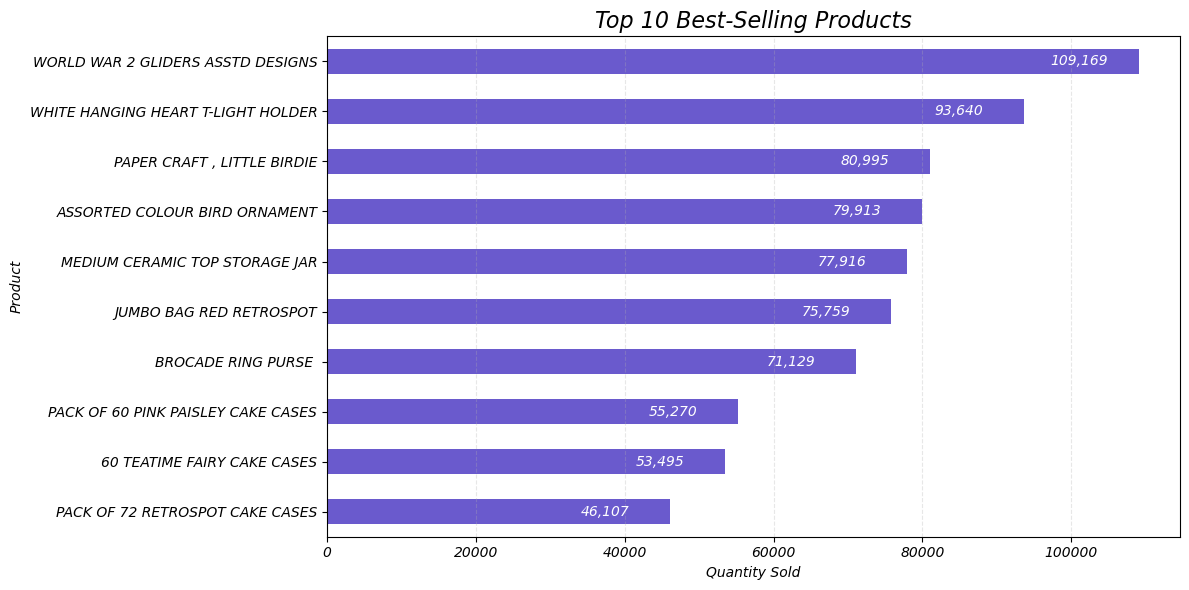

In [51]:
plt.figure(figsize=(12,6))

ax = top_products.sort_values().plot(
    kind='barh',
    color='#6A5ACD'
)

plt.title('Top 10 Best-Selling Products', fontsize=16)
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

for i, value in enumerate(top_products.sort_values()):
    ax.text(
        value - 12000,
        i,
        f'{value:,}',
        va='center',
        color='white',
        # fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Sales by Country

In [52]:
country_sales = (
    df_clean.groupby('Country')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    8705313
Netherlands        383977
EIRE               321703
France             273674
Denmark            237925
Germany            227983
Australia          104090
Sweden              88512
Switzerland         52337
Spain               50796
Name: Quantity, dtype: int64

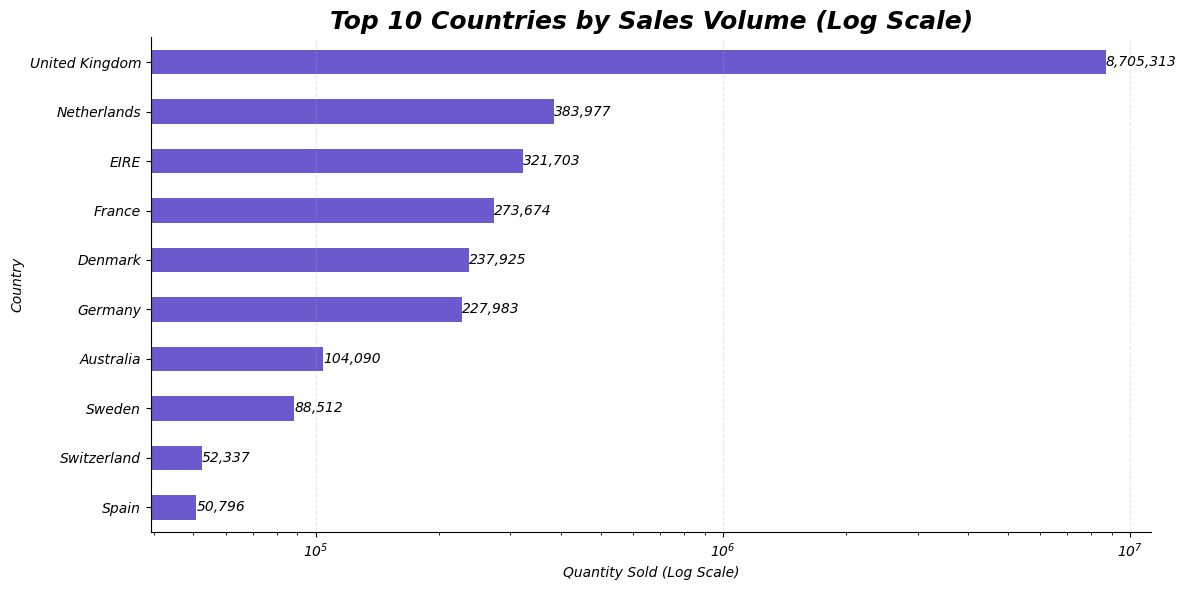

In [53]:
plt.figure(figsize=(12,6))

ax = country_sales.sort_values().plot(
    kind='barh',
    color='#6A5ACD'
)

plt.xscale('log')

plt.title(
    'Top 10 Countries by Sales Volume (Log Scale)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Quantity Sold (Log Scale)')
plt.ylabel('Country')

for i, value in enumerate(country_sales.sort_values()):
    ax.text(
        value,
        i,
        f'{value:,.0f}',
        va='center',
        fontsize=10
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

## Monthly Sales Trend

In [54]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']) #حولت التاريخ الى DateTime بدال String عشان البايثون يفهمه

df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M') #أنشئت عمود للشهر

#مبيعات كل شهر
monthly_sales = (
    df_clean.groupby('YearMonth')['Quantity']
    .sum()
)

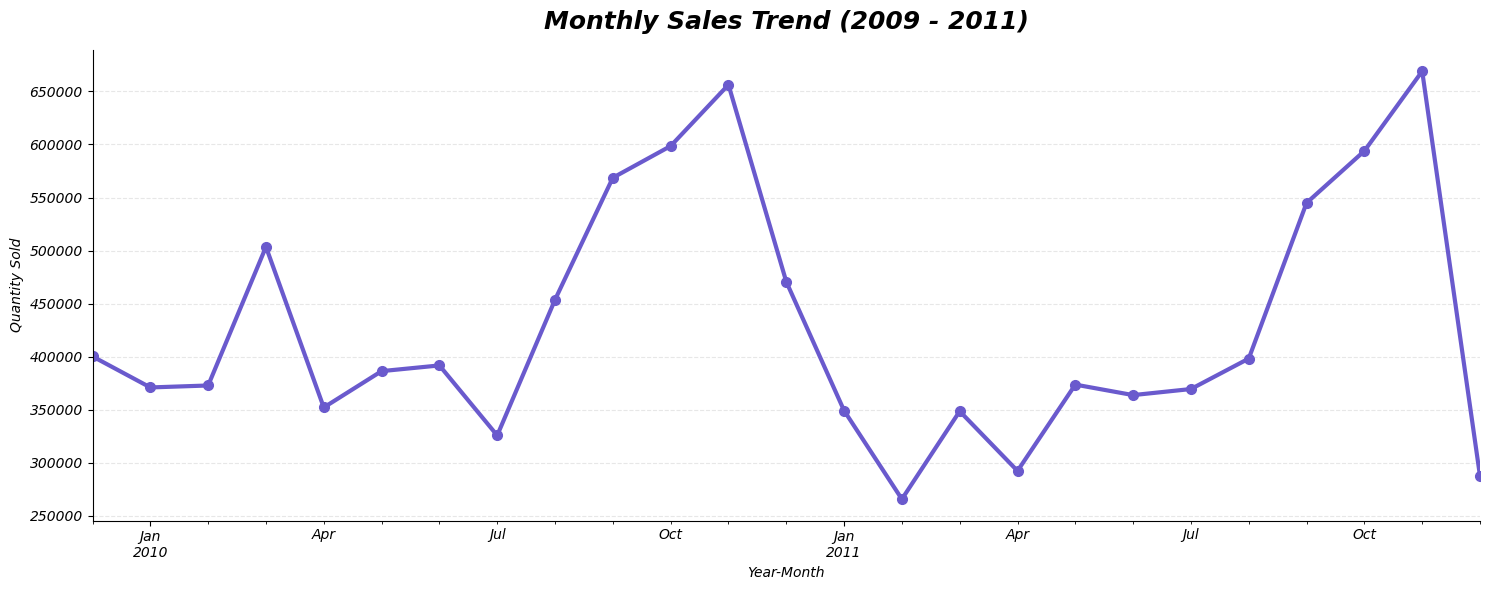

In [55]:
plt.figure(figsize=(15,6))

monthly_sales.plot(
    color='#6A5ACD',
    linewidth=3,
    marker='o',
    markersize=7
)

plt.title(
    'Monthly Sales Trend (2009 - 2011)',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Year-Month')
plt.ylabel('Quantity Sold')

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

## Top Customers Analysis

In [56]:
top_customers = (
    df_clean.groupby('Customer ID')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer ID
14646.0    367193
13902.0    220600
13694.0    189205
18102.0    188340
14156.0    165992
14911.0    149987
17511.0    119656
16684.0    104810
14298.0    100272
12415.0     91447
Name: Quantity, dtype: int64

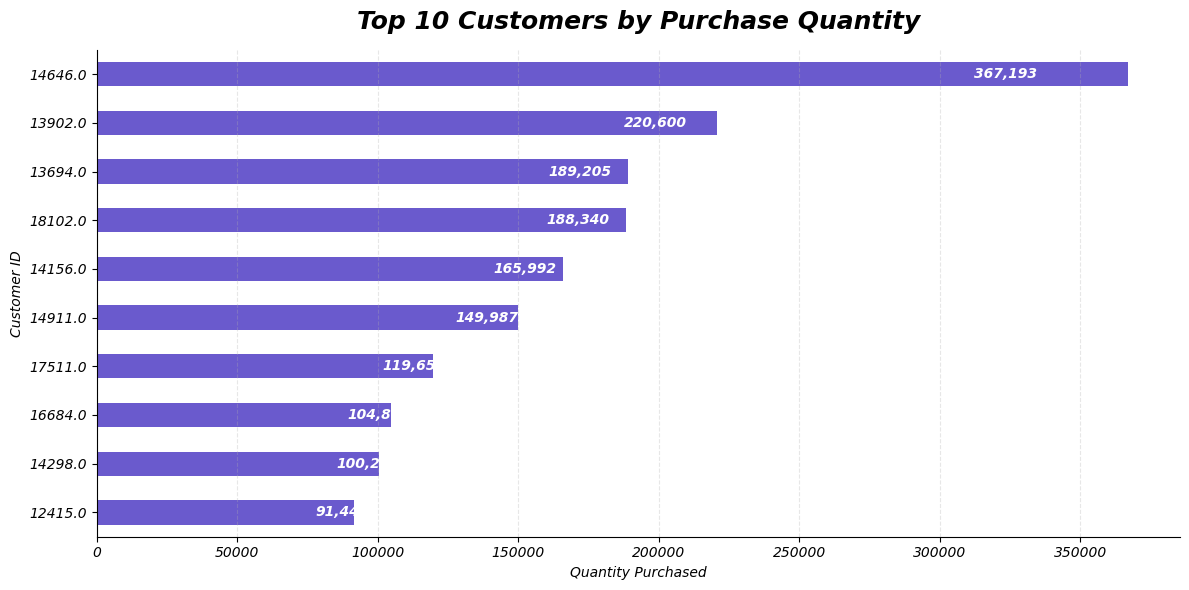

In [57]:
plt.figure(figsize=(12,6))

ax = top_customers.sort_values().plot(
    kind='barh',
    color='#6A5ACD'
)

plt.title(
    'Top 10 Customers by Purchase Quantity',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Quantity Purchased')
plt.ylabel('Customer ID')

for i, value in enumerate(top_customers.sort_values()):
    ax.text(
        value * 0.85,
        i,
        f'{value:,.0f}',
        va='center',
        color='white',
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

# Recommendation Models

## Popularity-Based Recommendation

In [58]:
popular_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

popular_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75759
BROCADE RING PURSE                     71129
PACK OF 60 PINK PAISLEY CAKE CASES     55270
60 TEATIME FAIRY CAKE CASES            53495
PACK OF 72 RETROSPOT CAKE CASES        46107
Name: Quantity, dtype: int64

In [59]:
def recommend_popular_products(n=5):
    return popular_products.head(n)

recommend_popular_products()

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
Name: Quantity, dtype: int64

## Association Rules (Market Basket Analysis)

In [60]:
from mlxtend.frequent_patterns import apriori, association_rules

In [61]:
basket = (
    df_clean.groupby(['Invoice', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

basket.head()

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489436,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489437,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
basket.shape

(36969, 5283)

In [64]:
top_items = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(100)
    .index
)

In [65]:
basket_small = basket[top_items]

basket_small.shape

(36969, 100)

In [66]:
frequent_items = apriori(
    basket_small,
    min_support=0.02,
    use_colnames=True
)

frequent_items.head()

,support,itemsets
0,0.024886,(WORLD WAR 2 GLIDERS ASSTD DESIGNS)
1,0.132219,(WHITE HANGING HEART T-LIGHT HOLDER)
2,0.071736,(ASSORTED COLOUR BIRD ORNAMENT)
3,0.070654,(JUMBO BAG RED RETROSPOT)
4,0.042684,(PACK OF 60 PINK PAISLEY CAKE CASES)


In [67]:
rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.044118,0.132219,0.031188,0.706928,5.346651,1.0,0.025355,2.960985,0.850489,0.214871,0.662275,0.471406
1,(WHITE HANGING HEART T-LIGHT HOLDER),(RED HANGING HEART T-LIGHT HOLDER),0.132219,0.044118,0.031188,0.235884,5.346651,1.0,0.025355,1.250964,0.936834,0.214871,0.200617,0.471406
2,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.031675,0.049176,0.022100,0.697694,14.187602,1.0,0.020542,3.145239,0.959922,0.376151,0.682059,0.573545
3,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.049176,0.031675,0.022100,0.449395,14.187602,1.0,0.020542,1.758656,0.977590,0.376151,0.431384,0.573545
4,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.047148,0.048121,0.023506,0.498566,10.360582,1.0,0.021237,1.898312,0.948185,0.327554,0.473216,0.493521


In [68]:
rules_display = rules[
    ['antecedents',
     'consequents',
     'support',
     'confidence',
     'lift']
].sort_values(
    by='lift',
    ascending=False
)

rules_display.head(10)

,antecedents,consequents,support,confidence,lift
2,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.022100,0.697694,14.187602
3,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.022100,0.449395,14.187602
4,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.023506,0.498566,10.360582
5,(HEART OF WICKER SMALL),(HEART OF WICKER LARGE),0.023506,0.488477,10.360582
9,(LUNCH BAG SPACEBOY DESIGN ),(LUNCH BAG BLACK SKULL.),0.020936,0.413020,7.645942
8,(LUNCH BAG BLACK SKULL.),(LUNCH BAG SPACEBOY DESIGN ),0.020936,0.387581,7.645942
7,(LUNCH BAG CARS BLUE),(LUNCH BAG BLACK SKULL.),0.020044,0.412354,7.633607
6,(LUNCH BAG BLACK SKULL.),(LUNCH BAG CARS BLUE),0.020044,0.371057,7.633607
1,(WHITE HANGING HEART T-LIGHT HOLDER),(RED HANGING HEART T-LIGHT HOLDER),0.031188,0.235884,5.346651
0,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.031188,0.706928,5.346651


### Top Association Rules

In [69]:
rules_display.head(10)

,antecedents,consequents,support,confidence,lift
2,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.022100,0.697694,14.187602
3,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.022100,0.449395,14.187602
4,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.023506,0.498566,10.360582
5,(HEART OF WICKER SMALL),(HEART OF WICKER LARGE),0.023506,0.488477,10.360582
9,(LUNCH BAG SPACEBOY DESIGN ),(LUNCH BAG BLACK SKULL.),0.020936,0.413020,7.645942
8,(LUNCH BAG BLACK SKULL.),(LUNCH BAG SPACEBOY DESIGN ),0.020936,0.387581,7.645942
7,(LUNCH BAG CARS BLUE),(LUNCH BAG BLACK SKULL.),0.020044,0.412354,7.633607
6,(LUNCH BAG BLACK SKULL.),(LUNCH BAG CARS BLUE),0.020044,0.371057,7.633607
1,(WHITE HANGING HEART T-LIGHT HOLDER),(RED HANGING HEART T-LIGHT HOLDER),0.031188,0.235884,5.346651
0,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.031188,0.706928,5.346651


## Collaborative Filtering (Customer Similarity)

In [70]:
user_item_matrix = (
    df_clean.groupby(['Customer ID', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

user_item_matrix.shape

(5878, 5283)

In [71]:
from sklearn.metrics.pairwise import cosine_similarity

In [72]:
customer_similarity = cosine_similarity(user_item_matrix)

customer_similarity.shape

(5878, 5878)

In [73]:
similarity_df = pd.DataFrame(
    customer_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

similarity_df.head()

Customer ID,12346.0,12347.0,12348.0,12349.0,12350.0,12351.0,12352.0,12353.0,12354.0,12355.0,...,18278.0,18279.0,18280.0,18281.0,18282.0,18283.0,18284.0,18285.0,18286.0,18287.0
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,1.000000,0.000000,0.000000,0.000002,0.000000,0.000000,2.554410e-07,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,8.762815e-07,0.000000
12347.0,0.000000,1.000000,0.150163,0.012990,0.018624,0.039675,2.385166e-02,0.020079,0.022923,0.378701,...,0.014905,0.0,0.020046,0.029441,0.011122,0.096903,0.026943,0.0,3.307103e-02,0.065679
12348.0,0.000000,0.150163,1.000000,0.000246,0.000316,0.000000,1.066435e-03,0.000000,0.012006,0.213272,...,0.000000,0.0,0.000000,0.000000,0.000000,0.170837,0.000000,0.0,0.000000e+00,0.063602
12349.0,0.000002,0.012990,0.000246,1.000000,0.029190,0.012112,1.198888e-01,0.206341,0.004445,0.021971,...,0.017490,0.0,0.001322,0.004706,0.006470,0.086155,0.052627,0.0,4.897702e-02,0.038543
12350.0,0.000000,0.018624,0.000316,0.029190,1.000000,0.000000,1.305029e-03,0.060057,0.000000,0.000000,...,0.000000,0.0,0.000000,0.072598,0.000000,0.022961,0.000000,0.0,3.069845e-02,0.000000


In [74]:
customer_id = user_item_matrix.index[0]

similar_customers = similarity_df[customer_id].sort_values(
    ascending=False
)

similar_customers.head(10)

Customer ID
12346.0    1.000000
15567.0    0.807065
17030.0    0.376196
16750.0    0.367405
15604.0    0.296229
12815.0    0.294509
14888.0    0.285391
18139.0    0.233751
16498.0    0.232148
18242.0    0.231220
Name: 12346.0, dtype: float64

In [75]:
# Select a target customer
customer_id = user_item_matrix.index[0]

# Find the most similar customer, excluding the customer itself
most_similar_customer = similarity_df[customer_id].drop(customer_id).sort_values(ascending=False).index[0]

most_similar_customer

np.float64(15567.0)

In [76]:
# Products purchased by the target customer
target_customer_products = user_item_matrix.loc[customer_id]
target_customer_products = target_customer_products[target_customer_products > 0].index

# Products purchased by the most similar customer
similar_customer_products = user_item_matrix.loc[most_similar_customer]
similar_customer_products = similar_customer_products[similar_customer_products > 0].index

# Recommend products bought by the similar customer but not by the target customer
recommendations = list(set(similar_customer_products) - set(target_customer_products))

recommendations[:5]

['BLUE PUDDING SPOON',
 'CUPBOARD 3 DRAWER MA CAMPAGNE',
 'HOMEMADE JAM SCENTED CANDLES',
 'SET OF 4 JAM JAR MAGNETS',
 'JAM CLOCK MAGNET']

In [77]:
recommendations_df = pd.DataFrame(
    recommendations[:5],
    columns=['Recommended Products']
)

recommendations_df

,Recommended Products
0,BLUE PUDDING SPOON
1,CUPBOARD 3 DRAWER MA CAMPAGNE
2,HOMEMADE JAM SCENTED CANDLES
3,SET OF 4 JAM JAR MAGNETS
4,JAM CLOCK MAGNET


# Model Comparison

In [78]:
comparison = pd.DataFrame({
    'Model': [
        'Popularity-Based',
        'Association Rules',
        'Collaborative Filtering'
    ],
    'Personalization Score': [1, 2, 3],
    'Complexity Score': [1, 2, 3],
    'Interpretability Score': [3, 3, 2]
})

comparison

,Model,Personalization Score,Complexity Score,Interpretability Score
0,Popularity-Based,1,1,3
1,Association Rules,2,2,3
2,Collaborative Filtering,3,3,2


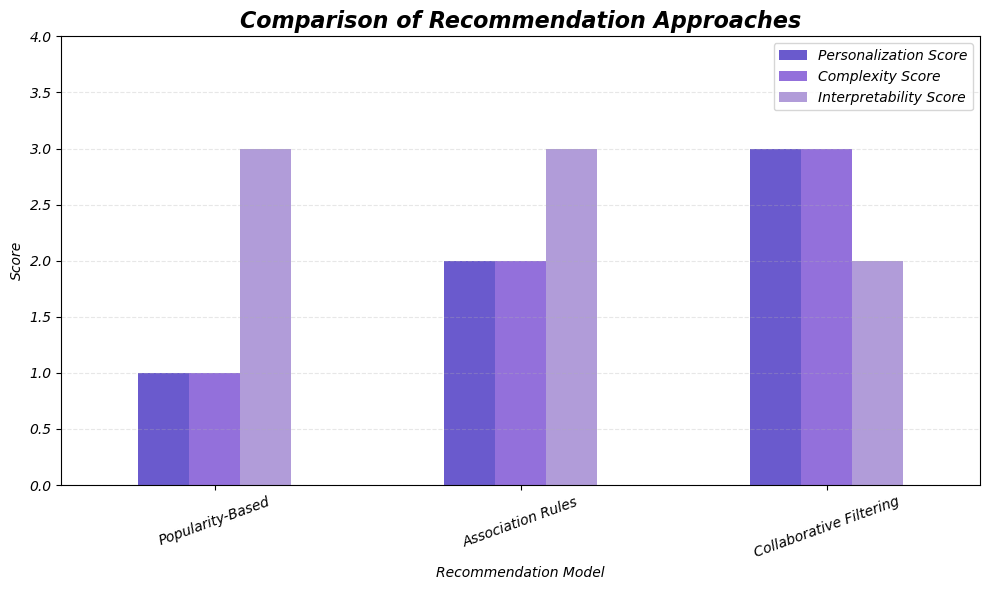

In [79]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6),
    color=['#6A5ACD', '#9370DB', '#B19CD9']
)

plt.title('Comparison of Recommendation Approaches', fontsize=16, fontweight='bold')
plt.xlabel('Recommendation Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 4)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()